<a href="https://colab.research.google.com/github/mirian2004/AI-AI-/blob/Day07/Day7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. 실험 환경 설정 (손실 함수 정의)
# 우리가 최소화할 목표 함수:
def loss_func(x):
  return (x**4) + (2*x**3) - 0.5*(x**2) + 4

# 시각화를 위한 x축 좌표 준비 (-5 ~ 5)
x_base = np.linspace(-5.5, 5.5, 100)
y_base = loss_func(x_base)

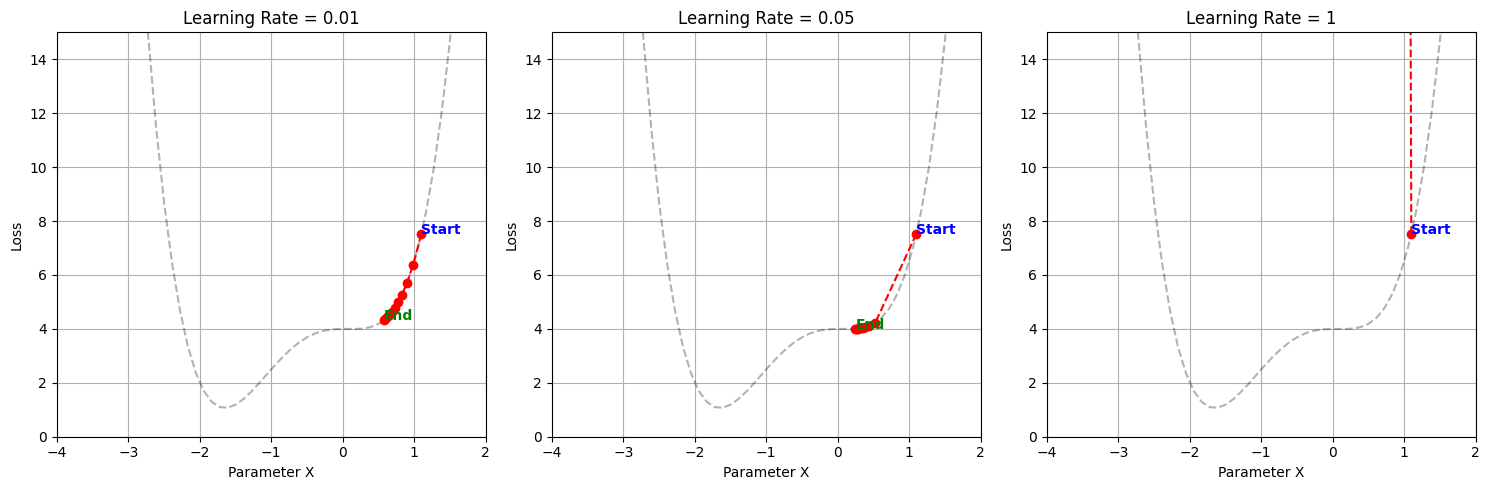

In [5]:
# 2. 학습률별 실험 진행
# 학습률(Learning Rate) 설정
learning_rates = [0.01, 0.05, 1]
epochs = 10

# 그래프 그리기 준비
plt.figure(figsize=(15, 5))

for i, lr in enumerate(learning_rates):

  # 파라미터 초기화
  x = torch.tensor([1.1], requires_grad=True)

  history_x = [x.item()]
  history_loss = [loss_func(x).item()]

  # 반복 학습 (Epoch)
  for epoch in range(epochs):
    # 1. Forward (Loss 계산)
    loss = loss_func(x)

    # 2. Backward (기울기 계산)
    loss.backward()

    # 3. 경사하강법 적용 (Gradient Descent)
    with torch.no_grad():
      x -= lr * x.grad
      x.grad.zero_()

    history_x.append(x.item())
    history_loss.append(loss_func(x).item())

  # 3. 결과 시각화
  plt.subplot(1,3,i+1)

  plt.plot(x_base, y_base, 'k--', alpha = 0.3, label='Loss Surface')
  plt.plot(history_x, history_loss,'ro--', label='Parameter Path')

  # 시작점과 끝점 표시
  plt.text(history_x[0], history_loss[0], 'Start', color='blue', fontweight='bold')
  plt.text(history_x[-1], history_loss[-1], 'End', color='green', fontweight='bold')

  plt.title(f"Learning Rate = {lr}")
  plt.xlabel('Parameter X')
  plt.ylabel('Loss')
  plt.grid(True)
  plt.xlim(-4,2)
  plt.ylim(0,15)

plt.tight_layout()
plt.show()


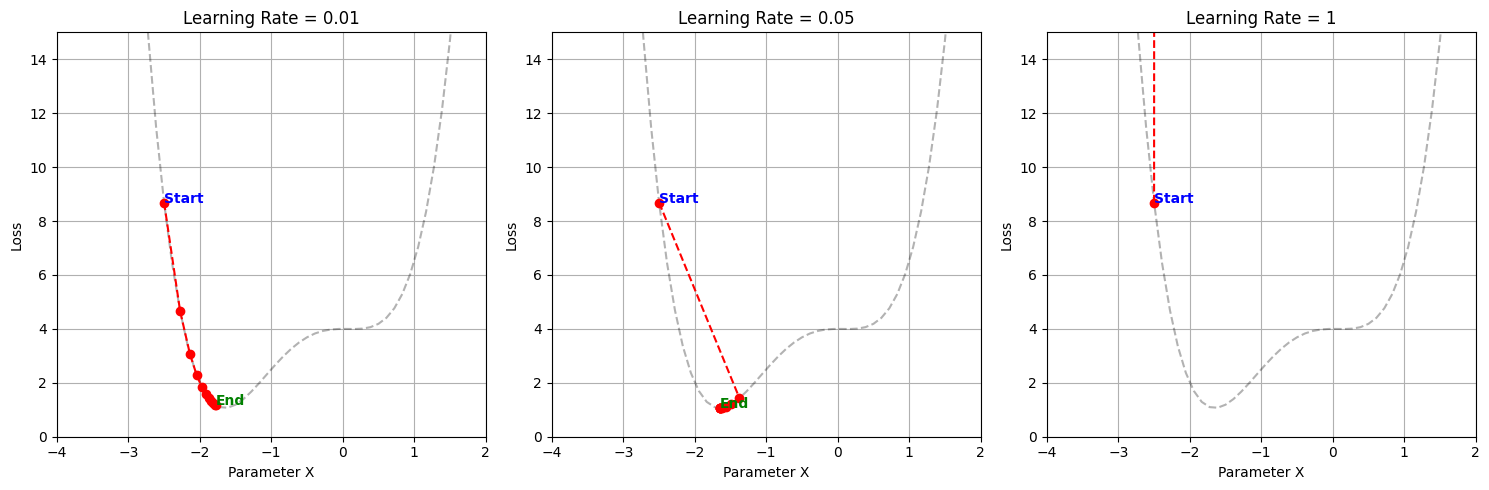

In [6]:
# 4. 파라미터 초기화에 따른 변화 관찰
# 그래프 그리기 준비
plt.figure(figsize=(15, 5))

for i, lr in enumerate(learning_rates):

    # 파라미터 초기화
    x = torch.tensor([-2.5], requires_grad=True)

    history_x = [x.item()]
    history_loss = [loss_func(x).item()]

    # 반복 학습 (Epoch)
    for epoch in range(epochs):
      # 1. Forward (Loss 계산)
      loss = loss_func(x)

      # 2. Backward (기울기 계산)
      loss.backward()

      # 3. 경사하강법 적용 (Gradient Descent)
      with torch.no_grad():
        x -= lr * x.grad
        x.grad.zero_()

      history_x.append(x.item())
      history_loss.append(loss_func(x).item())

    plt.subplot(1,3,i+1)

    plt.plot(x_base, y_base, 'k--', alpha = 0.3, label='Loss Surface')
    plt.plot(history_x, history_loss,'ro-', label='Parameter Path')

    # 시작점과 끝점 표시
    plt.text(history_x[0], history_loss[0], 'Start', color='blue', fontweight='bold')
    plt.text(history_x[-1], history_loss[-1], 'End', color='green', fontweight='bold')

    plt.title(f"Learning Rate = {lr}")
    plt.xlabel('Parameter X')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.xlim(-4,2)
    plt.ylim(0,15)

plt.tight_layout()
plt.show()